<a href="https://colab.research.google.com/github/tomlinsw9207/DATA-110/blob/main/HW3_BaggageClaim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 110.001/005 Homework 3:
## Baggage Claim Data
##### Fall 2026, Due Sunday, October 4, 2026 11:59pm

&nbsp;


**Be sure to save a copy of this notebook to your drive before you start working!!** You should also save a copy of the data set BaggageComplaints.csv to your own drive by right-clicking on the file and choosing "Make a copy."

Please complete this assignment by answering questions and writing code as indicated in each section. **You should answer the written questions and write the required code by yourself**, except where the assignment specifically says to use an AI coding assistant. When you are done:

1.   Save your work to a **PDF** for submission on **Gradescope**. Please make sure the PDF clearly display all of your answers, code and code output. If you have difficult to display all using Print to PDF, you may instead take screenshots of the entire Jupyter Notebook and organize the screenshots into a single PDF for submission.
2.   **Tag (match) pages to questions on Gradescope**
3.   Download the **.ipynb** file of your Colab notebook for submission on **Canvas**.

**Please name your file "Lastname_firstname_HW3.pdf" and ''Lastname_firstname_HW3.ipynb''**

**Penalties**:

 1. Failure to tag pages to questions on Gradescope: 2 points penalty

 2. Display issues: If a question has a display issue that prevents the grader from clearly viewing the answer, code, or code output, no points will be awarded for that question. Grading will be based solely on what is clearly shown in the submitted PDF.


**Background:** Anyone who travels by air knows that occasional problems are inevitable.  Flights can be delayed or cancelled due to weather conditions, mechanical problems, or labor strickes.  And, baggage can be lost, delayed, or damaged.  Given that many airlines are now charging for checked bags, issues with baggage are particularly annoying.  Baggage problems can have a serious impact on customer loyalty and can be costly to the airlines.

The data set contains monthly observations from 2004 to 2010 for United Airlines, American Eagle, and Hawaiian Airlines.  For each airline, the variables in the data set include:

**Baggage** - total number of passenger complaints for the month

**Scheduled** - total # of flights scheduled for that month

**Cancelled** - total # of flights cancelled for that month

**Enplaned** - total # of passengers who boarded a plane for that month


Data Visuzalization Techniques can help us understand which airlines do a better job of handling baggage; which airlines have the best and worst records; whether complaints are getting better or worse over time; what factors are affecting baggage complaints; etc





# Part 1: Getting Started (5pts)


In [ ]:
# import pandas and the necessary graphics packages and mount your google drive

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the data into a pandas dataframe

# Remember to change data_path!!
data_path = '/content/drive/MyDrive/UNC/26-27/DATA 110/HW3/BaggageComplaints.csv'
df = pd.read_csv(data_path)

# preview data
df.info()    #displays information about each column including its data type
df.head()    #prints the first five rows of the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Airline    252 non-null    object
 1   Date       252 non-null    object
 2   Month      252 non-null    int64 
 3   Year       252 non-null    int64 
 4   Baggage    252 non-null    int64 
 5   Scheduled  252 non-null    int64 
 6   Cancelled  252 non-null    int64 
 7   Enplaned   252 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 15.9+ KB


,Airline,Date,Month,Year,Baggage,Scheduled,Cancelled,Enplaned
0,American Eagle,Jan-04,1,2004,12502,38276,2481,992360
1,American Eagle,Feb-04,2,2004,8977,35762,886,1060618
2,American Eagle,Mar-04,3,2004,10289,39445,1346,1227469
3,American Eagle,Apr-04,4,2004,8095,38982,755,1234451
4,American Eagle,May-04,5,2004,10618,40422,2206,1267581


Ultimately, the goal of this analysis is to understand more about baggage claims.  However, you expect that baggage claims might be affected by the number of flights scheduled, the number of passengers travelling, and the number of flights cancelled.

With that in mind, you should begin by examining the distribution of each of those variables.

Q1: Generate histograms for Baggage, Scheduled, Cancelled, and Enplaned.

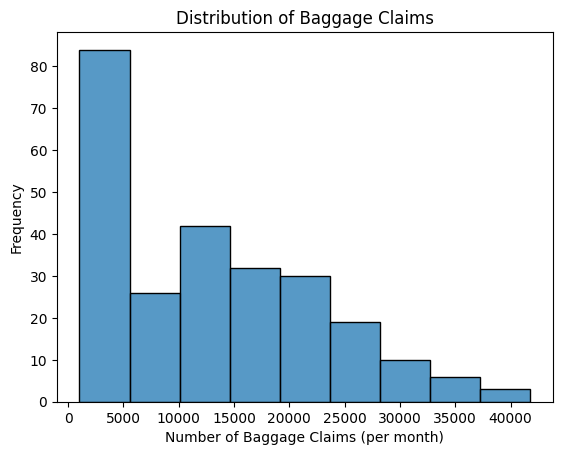

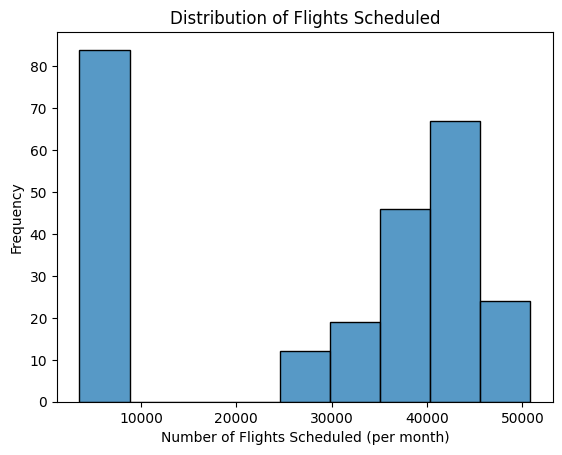

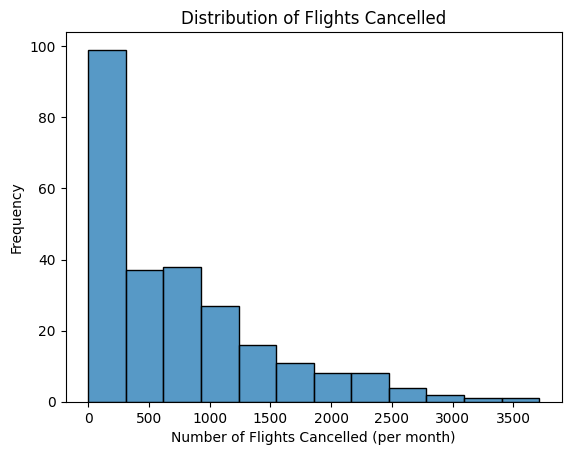

Text(0, 0.5, 'Frequency')

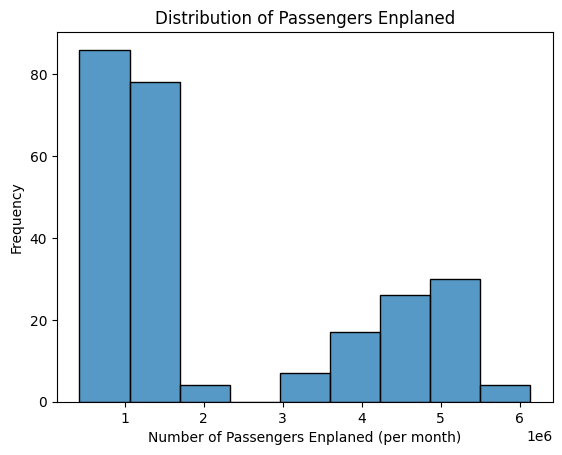

In [ ]:
# Histogram for Baggage
plt.figure()
sns.histplot(data=df, x='Baggage')
plt.title('Distribution of Baggage Claims')
plt.xlabel('Number of Baggage Claims (per month)')
plt.ylabel('Frequency')
plt.show()


# Histogram for Scheduled
plt.figure()
sns.histplot(data=df, x='Scheduled')
plt.title('Distribution of Flights Scheduled')
plt.xlabel('Number of Flights Scheduled (per month)')
plt.ylabel('Frequency')
plt.show()


# Histogram for Cancelled
plt.figure()
sns.histplot(data=df, x='Cancelled')
plt.title('Distribution of Flights Cancelled')
plt.xlabel('Number of Flights Cancelled (per month)')
plt.ylabel('Frequency')
plt.show()


# Histogram for Enplaned
plt.figure()
sns.histplot(data=df, x='Enplaned')
plt.title('Distribution of Passengers Enplaned')
plt.xlabel('Number of Passengers Enplaned (per month)')
plt.ylabel('Frequency')


Q2: What observations can you make based on these histograms?  Specifically, what is the shape of the distribution for each variable?  Do you notice any potential outliers in the distributions?  Are any of the distributions multi-modal?  Anything else that stands out as being interesting or unusual for any of the distributions?

A:
Baggage Claims appears to be right skewed.
Flights Scheduled appears to be left skewed with outliers around 10000 flights sccheduled per month.
Flights Cancelled is right skewed.
Passengers Enplaned appears to be multimodal, with a higher frequency around 1 to 2 people.




# Part 2: Comparing Airlines (10pts)

Q3: The distributions of Scheduled and Enplaned warrant some further investigation to determine whether a second factor (like airline) might be affecting the distributions.  The following code overlays airline with the histogram for Scheduled.  You will need to write code to create a simliar plot that overlays airline on the histogram for Enplaned.

What do these graphs tell you about the multimodal behavior of the histograms for these two variables?

A: It appears that American Airlines and Hawaiian airlines have data that differs from United.

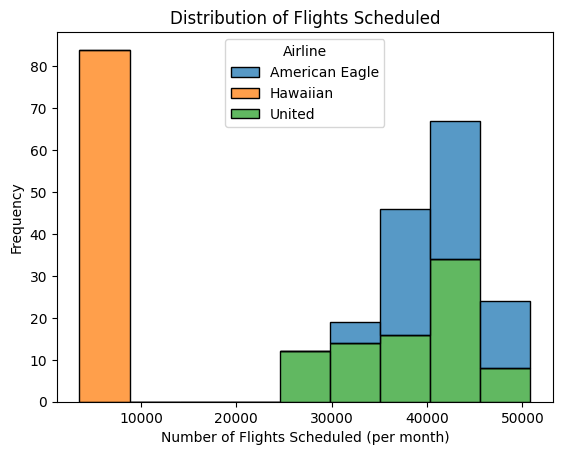

Text(0, 0.5, 'Frequency')

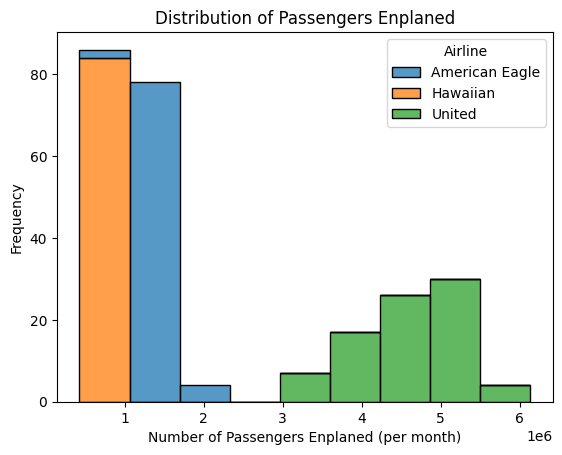

In [13]:
# Histogram of Scheduled overlaid with Airline
plt.figure()
sns.histplot(data=df, x='Scheduled', hue='Airline', multiple='stack')
plt.title('Distribution of Flights Scheduled')
plt.xlabel('Number of Flights Scheduled (per month)')
plt.ylabel('Frequency')
plt.show()

# Histogram of Enplaned overlaid with Airline
plt.figure()
sns.histplot(data=df, x='Enplaned', hue='Airline', multiple='stack')
plt.title('Distribution of Passengers Enplaned')
plt.xlabel('Number of Passengers Enplaned (per month)')
plt.ylabel('Frequency')



Q4: For each airline, generate the descriptive statistics of Baggage, Scheduled, Cancelled, and Enplaned.  (HINT: Use grouby with describe)

Based on this information, do you think it's fair to compare Hawaiian airlines directly to American Eagle and United?  Why or why not? (HINT: pay particular attention to the number of scheduled flights)

A: No, I don't think it fair to compare Hawaiian directly to American Eagle and United. The amount of scheduled Hawaiian flights is much lower than the other airlines.


In [35]:
import pandas as pd

# Adjust pandas settings to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Calculate descriptive statistics by airline and display
groupby = df.groupby('Airline')
display(groupby.describe())

Month                                             Year                                                           Baggage                                                                          Scheduled                                                                           Cancelled                                                                  Enplaned                                                                                      Cancelled_zscore                                                                      
               count mean       std  min   25%  50%   75%   max count    mean       std     min     25%     50%     75%     max   count          mean          std     min       25%      50%       75%      max     count          mean          std      min       25%      50%       75%      max     count         mean         std    min     25%     50%      75%     max    count          mean            std        min         25%        50%        75%        max            count      mean       std       min       25%       50%       75%       max
Airline                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
American Eagle  84.0  6.5  3.472786  1.0  3.75  6.5  9.25  12.0  84.0  2007.0  2.012012  2004.0  2005.0  2007.0  2009.0  2010.0    84.0  14619.202381  5695.836168  7052.0   9960.00  13111.0  19017.75  28556.0      84.0  41314.047619  4187.570147  31965.0  37328.25  42021.0  44963.25  48096.0      84.0  1414.761905  717.422740  266.0  885.25  1341.0  1828.50  3712.0     84.0  1.396726e+06  166162.311692   992360.0  1290414.75  1391112.5  1509907.5  1727570.0             84.0  0.954954  0.963580 -0.587964  0.243759  0.855883  1.510651  4.040405
Hawaiian        84.0  6.5  3.472786  1.0  3.75  6.5  9.25  12.0  84.0  2007.0  2.012012  2004.0  2005.0  2007.0  2009.0  2010.0    84.0   1621.559524   424.095106  1033.0   1304.75   1516.5   1907.50   2791.0      84.0   4844.678571   820.989121   3553.0   4135.50   4681.0   5541.25   6645.0      84.0    17.892857   24.070187    0.0    5.00    11.0    25.25   151.0     84.0  5.941742e+05  103423.508819   423446.0   506974.00   580140.0   681299.5   819776.0             84.0 -0.921200  0.032329 -0.945232 -0.938517 -0.930458 -0.911319 -0.742422
United          84.0  6.5  3.472786  1.0  3.75  6.5  9.25  12.0  84.0  2007.0  2.012012  2004.0  2005.0  2007.0  2009.0  2010.0    84.0  21599.761905  7829.877478  8597.0  15385.25  19986.5  26619.50  41787.0      84.0  38225.297619  6119.894736  26091.0  32431.75  40330.5  42288.75  50837.0      84.0   678.630952  423.604009  104.0  397.75   617.5   800.50  2272.0     84.0  4.620712e+06  662232.057718  3155234.0  4118253.75  4628089.0  5119373.5  6137271.0             84.0 -0.033754  0.568948 -0.805548 -0.411009 -0.115860  0.129930  2.106322

# Part 3: Comparing American Eagle and United (10pts)

Q5: Create a new dataframe that contains only American Eagle and United Airlines.  

In [32]:
# Create a new dataframe that contains only American Eagle and United Airlines
df2 = df[df['Airline'].isin(['American Eagle', 'United'])]
df2.head()

,Airline,Date,Month,Year,Baggage,Scheduled,Cancelled,Enplaned
0,American Eagle,Jan-04,1,2004,12502,38276,2481,992360
1,American Eagle,Feb-04,2,2004,8977,35762,886,1060618
2,American Eagle,Mar-04,3,2004,10289,39445,1346,1227469
3,American Eagle,Apr-04,4,2004,8095,38982,755,1234451
4,American Eagle,May-04,5,2004,10618,40422,2206,1267581


In [37]:
# Calculate and display descriptive statistics for American Eagle and United only
display(df2.groupby('Airline').describe())

Month                                             Year                                                           Baggage                                                                          Scheduled                                                                           Cancelled                                                                 Enplaned                                                                                      Cancelled_zscore                                                                     
               count mean       std  min   25%  50%   75%   max count    mean       std     min     25%     50%     75%     max   count          mean          std     min       25%      50%       75%      max     count          mean          std      min       25%      50%       75%      max     count         mean         std    min     25%     50%     75%     max    count          mean            std        min         25%        50%        75%        max            count     mean       std       min       25%       50%       75%       max
Airline                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
American Eagle  84.0  6.5  3.472786  1.0  3.75  6.5  9.25  12.0  84.0  2007.0  2.012012  2004.0  2005.0  2007.0  2009.0  2010.0    84.0  14619.202381  5695.836168  7052.0   9960.00  13111.0  19017.75  28556.0      84.0  41314.047619  4187.570147  31965.0  37328.25  42021.0  44963.25  48096.0      84.0  1414.761905  717.422740  266.0  885.25  1341.0  1828.5  3712.0     84.0  1.396726e+06  166162.311692   992360.0  1290414.75  1391112.5  1509907.5  1727570.0             84.0  0.53214  1.037232 -1.128711 -0.233415  0.425497  1.130312  3.853429
United          84.0  6.5  3.472786  1.0  3.75  6.5  9.25  12.0  84.0  2007.0  2.012012  2004.0  2005.0  2007.0  2009.0  2010.0    84.0  21599.761905  7829.877478  8597.0  15385.25  19986.5  26619.50  41787.0      84.0  38225.297619  6119.894736  26091.0  32431.75  40330.5  42288.75  50837.0      84.0   678.630952  423.604009  104.0  397.75   617.5   800.5  2272.0     84.0  4.620712e+06  662232.057718  3155234.0  4118253.75  4628089.0  5119373.5  6137271.0             84.0 -0.53214  0.612436 -1.362927 -0.938230 -0.620521 -0.355945  1.771513

Q6: Using the new dataframe created in Q5, create a box plot to again examine the distributions of Baggage, Scheduled, Cancelled, and Enplaned.  Code to create the first boxplot for Baggage is included as an example below.

**Note** When examining the boxplot for Cancelled, notice all of the dots that are at the top of the graph.  Any dots that appear above (or below) the main part of the graph are considered to be outliers.

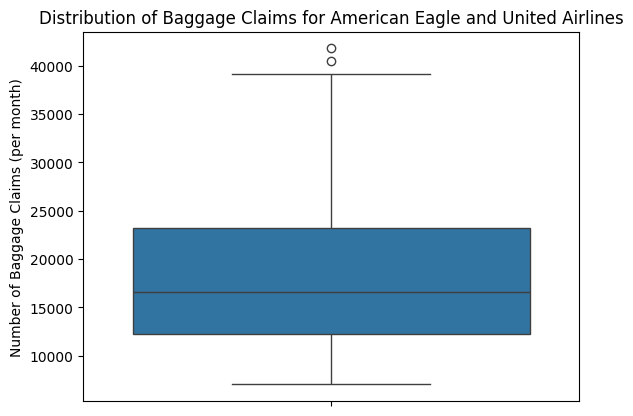

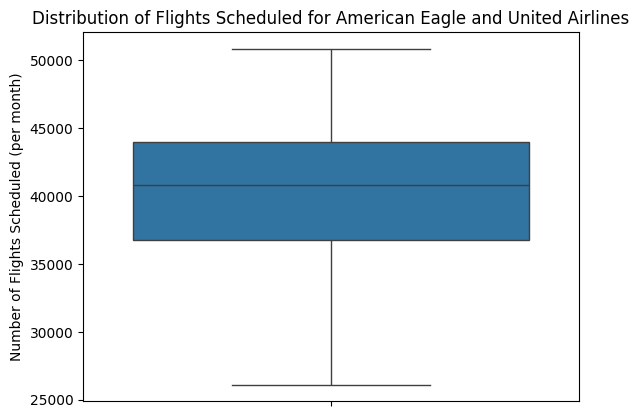

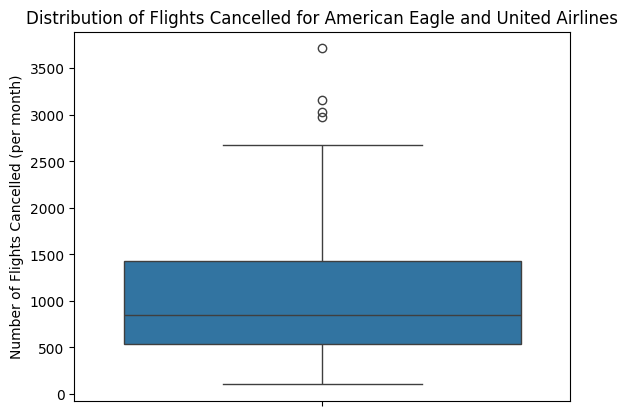

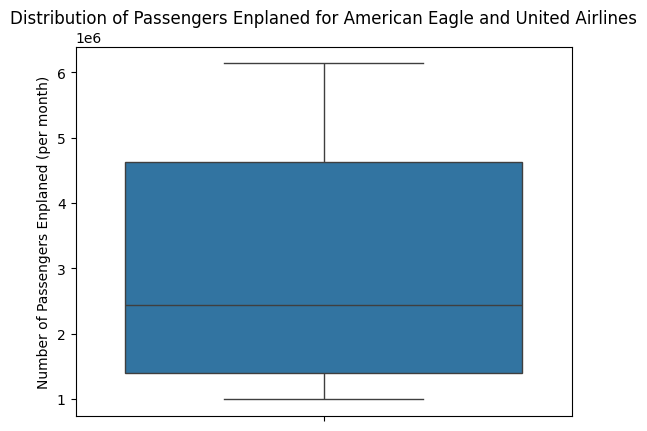

In [23]:
# Create a Boxplot to display the distribution of Baggage

plt.figure()
sns.boxplot(data=df2, y="Baggage")
plt.title("Distribution of Baggage Claims for American Eagle and United Airlines")
plt.ylabel("Number of Baggage Claims (per month)")
plt.show()

# Create a Boxplot to display the distribution of Scheduled

plt.figure()
sns.boxplot(data=df2, y="Scheduled")
plt.title("Distribution of Flights Scheduled for American Eagle and United Airlines")
plt.ylabel("Number of Flights Scheduled (per month)")
plt.show()


# Create a Boxplot to display the distribution of Cancelled

plt.figure()
sns.boxplot(data=df2, y="Cancelled")
plt.title("Distribution of Flights Cancelled for American Eagle and United Airlines")
plt.ylabel("Number of Flights Cancelled (per month)")
plt.show()


# Create a Boxplot to display the distribution of Enplaned

plt.figure()
sns.boxplot(data=df2, y="Enplaned")
plt.title("Distribution of Passengers Enplaned for American Eagle and United Airlines")
plt.ylabel("Number of Passengers Enplaned (per month)")
plt.show()



# Part 4: Identifying Outliers (5pts)

There are a number of different ways to identify outliers.  One way is to identify them visually (as you did with the boxplot in Question 6).  Another way is to determine how many standard deviations the observations are away from the mean.

In class, we discussed the idea that any obsveration that is more than three standard deviations away from the mean could be considered a potential outlier.  The z-score (or standardized value) for a variable simply take the value of the variable, subtracts the mean, and divides by the standard deviation.  The z-score tells you how many standard deviations away from the mean that particular observation is.

To simplify and automate the process of finding the z-score, you can use a function in Python called StandardScaler (which can be found in the sklearn pacakage).

Q7: Use the AI coding assistant to help you write code that will create a new column that contains the z-scores for Cancelled.  Ask the AI assistant to use StandardScalar to create the z-scores.  Then, create a new dataframe that contains only those observations for which the z-score for cancelled is greater than or equal to 3 and print that dataframe.

What do you notice about the outliers that you identified?

(Note: You don't need to include the prompt for your homework. We will grade based on the actual code and output results.)


A: 2006 and 2007 there are a lot of outliers, and overall they occur in the winter months.


In [38]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Calculate z-scores for Cancelled flights using df2 and save them to a new column
df2 = df2.copy()  # Avoid SettingWithCopyWarning
df2['Cancelled_zscore'] = scaler.fit_transform(df2[['Cancelled']])

# Filter for observations with a z-score greater than or equal to 3
outliers_df2 = df2[df2['Cancelled_zscore'] >= 3]

# Display the outliers
display(outliers_df2)

,Airline,Date,Month,Year,Baggage,Scheduled,Cancelled,Enplaned,Cancelled_zscore
12,American Eagle,Jan-05,1,2005,15361,43009,3152,1185194,3.043795
47,American Eagle,Dec-07,12,2007,23762,44559,3712,1363546,3.853429


In [39]:
# Show the maximum z-score for each airline to see how close United got
max_z_scores = df2.groupby('Airline')['Cancelled_zscore'].max().reset_index()
print("Maximum Cancellation Z-Score by Airline:")
display(max_z_scores)

# Let's show the top 5 highest cancellation months for BOTH airlines
top_cancelled = df2.groupby('Airline').apply(lambda x: x.nlargest(5, 'Cancelled')).reset_index(drop=True)
print("\nTop 5 Cancellation Months for Each Airline:")
display(top_cancelled[['Airline', 'Date', 'Cancelled', 'Cancelled_zscore']])

Maximum Cancellation Z-Score by Airline:


,Airline,Cancelled_zscore
0,American Eagle,3.853429
1,United,1.771513



Top 5 Cancellation Months for Each Airline:


/tmp/ipykernel_6083/812097737.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_cancelled = df2.groupby('Airline').apply(lambda x: x.nlargest(5, 'Cancelled')).reset_index(drop=True)


,Airline,Date,Cancelled,Cancelled_zscore
0,American Eagle,Dec-07,3712,3.853429
1,American Eagle,Jan-05,3152,3.043795
2,American Eagle,Feb-08,3025,2.860181
3,American Eagle,Feb-07,2976,2.789338
4,American Eagle,Jun-07,2669,2.345486
5,United,Dec-07,2272,1.771513
6,United,Dec-06,2229,1.709345
7,United,Feb-07,1863,1.180191
8,United,Feb-08,1519,0.682845
9,United,Jan-08,1481,0.627905


# Part 5: Examining the relationship between two variables (10pts)

## Relationship between a categorical and a numerical variable

While there are many ways to examine the relationship between a categorical and a numerical variable, one useful visual is a **comparative box plot.**  The x-axis lists all of the levels of the categorical variable, and then separate boxplots illustrating the distribution of a numeric variable are displayed for each category.

This visual allows you to compare the average or median value of the numeric variable by focusing on the **center of the box** (do the boxes have a similar height on the vertical axis, or is one box much higher or much lower than the other).  This visual also allows you to compare the variability of the distributions by comparing the **distance** from the very top to the very bottom of the figure.  The bigger that distance, the more variability that exists, and the smaller that distance, the less variability that exists.  

The following code creates a comparative boxplot that helps to answer the question:  



Q8: Is there a difference in the number of baggage claims per month for American Eagle vs United airlines?  What do you notice about the means?  Is one higher or lower?  What do you notice about the variability?  Is one more or less variable than the other?

A: There is a difference in the number of baggage claims per month for both the airlines. United has a higher mean than American, so they likely have a higher average amount of claims per month. United has a wider plot, which shows that there is more variablility compared to American.

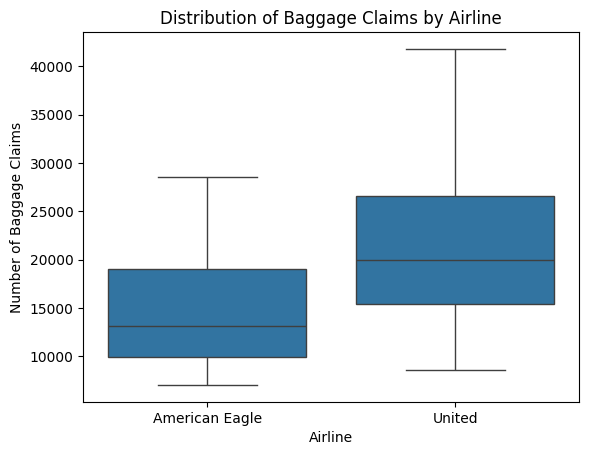

In [40]:
# Create a comparative boxplot to display the distribution of Baggage by Airline
plt.figure()
sns.boxplot(data=df2, x='Airline', y='Baggage')
plt.title('Distribution of Baggage Claims by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Baggage Claims')
plt.show()

## Relationship between 2 numerical variables

A scatterplot is an effective way of examining the relationship between two numerical variables.  When examining a scatterplot, you are trying to identify trends and patterns.  Do the values of one variable increase as the other one increases?  Do the values of one variable decrease as the other one increases?  Does the pattern appear to be linear or curved or flat?



Q9: The code below generates a scatterplot of Baggage vs Cancelled (since most people believe that cancelled flights can result in delayed or lost baggage).

What do you observe about the relationship between cancelled flights and baggage claims based on this graph.

The second graph illustrates the relationship between baggage claims and cancelled flights but colors the values by airline and includes trend lines for each airline.

How does this change your perception of the relationship between baggage claims and cancelled flights if at all?

A: It looks like there is a correlation between how many flights are cancelled and how many baggage claims there are. The second plot shows that there is a positive correlation, but the airlines have different amounts of cancelled flights and baggage claims.

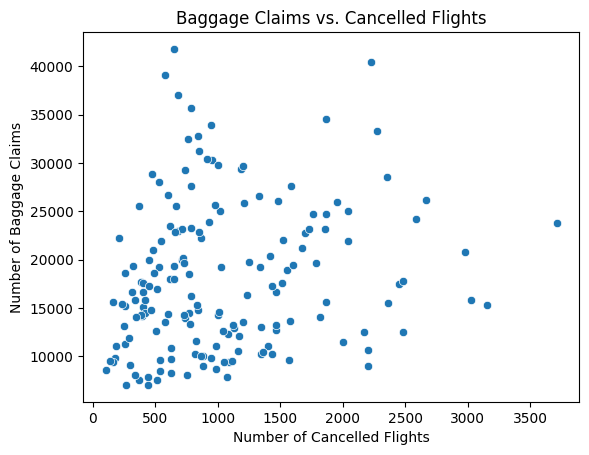

<Figure size 640x480 with 0 Axes>

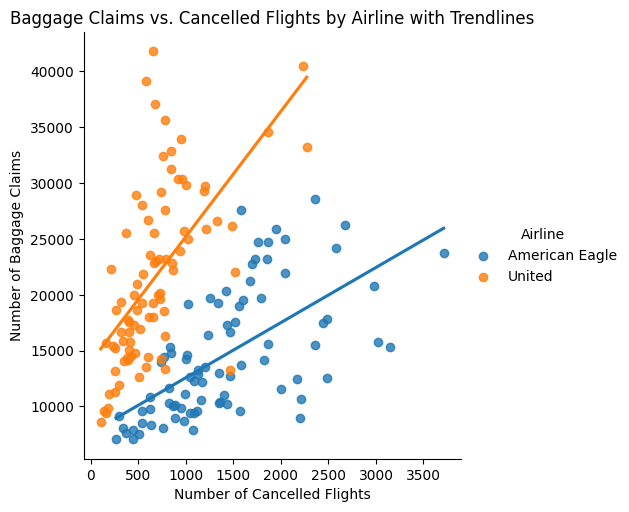

In [41]:
# Scatterplot of Baggage vs Cancelled
plt.figure()
sns.scatterplot(data=df2, x='Cancelled', y='Baggage')
plt.title('Baggage Claims vs. Cancelled Flights')
plt.xlabel('Number of Cancelled Flights')
plt.ylabel('Number of Baggage Claims')
plt.show()

# Scatterplot of Baggage vs Cancelled with color by Airline and trendlines
plt.figure()
sns.lmplot(data=df2, x='Cancelled', y='Baggage', hue='Airline', ci=None)
plt.title('Baggage Claims vs. Cancelled Flights by Airline with Trendlines')
plt.xlabel('Number of Cancelled Flights')
plt.ylabel('Number of Baggage Claims')
plt.show()

# Part 6: Further Exploration and Conclusions (10pts)

You now have an initial exploratory analysis of these data.  However, there are other things that could be explored.  For example, how are the other numeric variables impacting the number of baggage claims?  How are other categorical variables like month of the year impacting baggage claims?

Q10:  Choose at least one other relationship or aspect of the data to explore and create an appropriate graph to provide some insight.  After you are done exploring, answer the following question:

What has this lab exercise revealed about baggage claims?  And, if you were worried about your bags arriving safely on time at your destination, which airline would you choose and why?

A: This has shown me that there are more baggage claims when flights are cancelled. The holidays and the summer time increase the likelihood of baggage being lost. If I was concerned about my bags, I would probably choose American because when flights are cancelled they are less likely to lose the baggage.

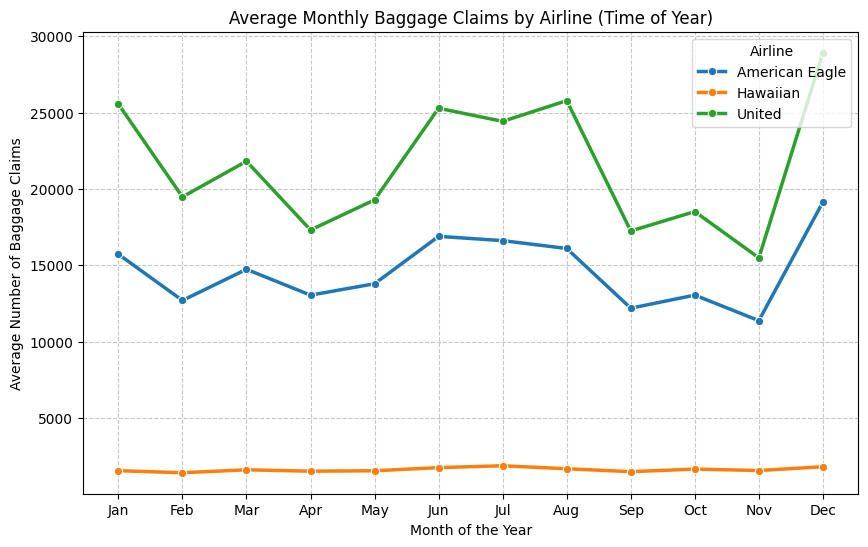

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average baggage claims per month for each airline
monthly_baggage = df.groupby(['Airline', 'Month'])['Baggage'].mean().reset_index()

# Create a line plot to visualize baggage claims over the months of the year
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_baggage, x='Month', y='Baggage', hue='Airline', marker='o', linewidth=2.5)

plt.title('Average Monthly Baggage Claims by Airline (Time of Year)')
plt.xlabel('Month of the Year')
plt.ylabel('Average Number of Baggage Claims')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Airline')
plt.show()